# Analysis of the Arkouda Benchmarks

This notebook is used to do the data analysis of the Arkouda benchmarks. \
This analysis is being done on the Arkouda HPC cluster it self, \
serving both as a dogfooding exercise as well as a proof of usability.

In [8]:
### importing modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams


In [9]:
## Importing the data

df = pd.read_json('/home/jon/Desktop/proj/BachelorsThesis/Project/data/pod-startup-time/small-image-1713744112.json', lines=True)

df = df[df['conditions'].apply(lambda x: all(d['status'] == "True" for d in x['conditions']))].join(
    df['conditions'].apply(lambda x: {d['type']: d['lastTransitionTime'] for d in x['conditions']}).apply(pd.Series)
).drop('conditions', axis=1)


df


,deployment_type,start_time,end_time,duration,Initialized,Ready,ContainersReady,PodScheduled
0,warm,2024-04-22 00:02:33,2024-04-22 00:02:37,4,2024-04-22T00:02:34Z,2024-04-22T00:02:37Z,2024-04-22T00:02:37Z,2024-04-22T00:02:34Z
1,warm,2024-04-22 00:02:43,2024-04-22 00:02:48,5,2024-04-22T00:02:44Z,2024-04-22T00:02:47Z,2024-04-22T00:02:47Z,2024-04-22T00:02:44Z
2,warm,2024-04-22 00:02:54,2024-04-22 00:02:58,4,2024-04-22T00:02:55Z,2024-04-22T00:02:58Z,2024-04-22T00:02:58Z,2024-04-22T00:02:55Z
3,warm,2024-04-22 00:03:05,2024-04-22 00:03:09,4,2024-04-22T00:03:06Z,2024-04-22T00:03:09Z,2024-04-22T00:03:09Z,2024-04-22T00:03:06Z
4,warm,2024-04-22 00:03:15,2024-04-22 00:03:20,5,2024-04-22T00:03:16Z,2024-04-22T00:03:20Z,2024-04-22T00:03:20Z,2024-04-22T00:03:16Z
...,...,...,...,...,...,...,...,...
395,cold,2024-04-22 03:02:58,2024-04-22 03:03:26,28,2024-04-22T03:02:59Z,2024-04-22T03:03:26Z,2024-04-22T03:03:26Z,2024-04-22T03:02:59Z
396,cold,2024-04-22 03:03:47,2024-04-22 03:04:07,20,2024-04-22T03:03:49Z,2024-04-22T03:04:06Z,2024-04-22T03:04:06Z,2024-04-22T03:03:49Z
397,cold,2024-04-22 03:04:25,2024-04-22 03:04:53,28,2024-04-22T03:04:27Z,2024-04-22T03:04:53Z,2024-04-22T03:04:53Z,2024-04-22T03:04:27Z
398,cold,2024-04-22 03:05:13,2024-04-22 03:05:42,29,2024-04-22T03:05:14Z,2024-04-22T03:05:42Z,2024-04-22T03:05:42Z,2024-04-22T03:05:14Z


In [10]:

# Remove values where the condition is false (i.e. the pod is not ready)


# Convert columns to datetime and remove timezone information
time_columns = ['start_time', 'end_time', 'Initialized', 'Ready', 'ContainersReady', 'PodScheduled']
for col in time_columns:
    df[col] = pd.to_datetime(df[col], utc=True).dt.tz_convert(None) 

# Calculate time deltas
df['time_to_scheduled'] = (df['PodScheduled'] - df['start_time']).dt.total_seconds()
df['time_to_initialized'] = (df['Initialized'] - df['PodScheduled']).dt.total_seconds()
df['time_to_containers_ready'] = (df['ContainersReady'] - df['PodScheduled']).dt.total_seconds()


steps = ['time_to_scheduled','time_to_initialized', 'time_to_containers_ready']
grouped_mean = df.groupby('deployment_type')[steps].mean()
grouped_std = df.groupby('deployment_type')[steps].std()

print(grouped_mean)

                 time_to_scheduled  time_to_initialized  \
deployment_type                                           
cold                          1.23                  0.0   
warm                          1.22                  0.0   

                 time_to_containers_ready  
deployment_type                            
cold                                20.67  
warm                                 2.63  


/tmp/ipykernel_747379/4239653972.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i -0.1, grouped_mean['time_to_scheduled'][i] , round(grouped_mean['time_to_scheduled'][i], 2), ha='center', va='bottom', color='blue')
/tmp/ipykernel_747379/4239653972.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i +0.1, grouped_mean['time_to_containers_ready'][i] +1.5, round(grouped_mean['time_to_containers_ready'][i], 2), ha='center', va='bottom', color='green')


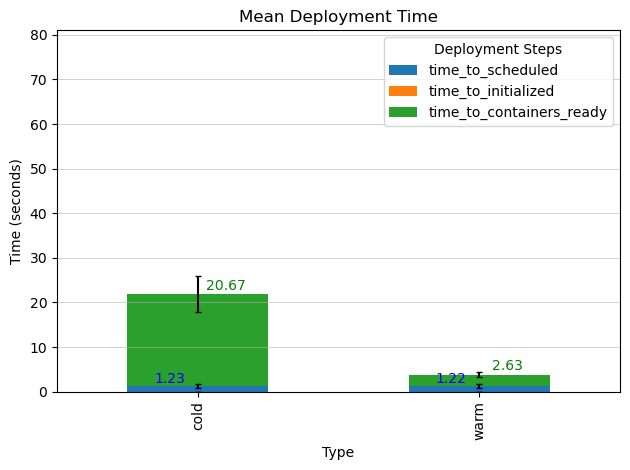

<Figure size 640x480 with 0 Axes>

In [11]:

# Define the scale limits
min_value = 0
max_value = 81

grouped_mean.plot(kind='bar', yerr=grouped_std, capsize=2, stacked=True)

# Set the same scale for the y-axis
plt.ylim(min_value, max_value)
plt.grid(True, which='both', linestyle='-', linewidth=0.4, axis='y') 
plt.title('Mean Deployment Time')
plt.xlabel('Type')
plt.ylabel('Time (seconds)')
plt.legend(title='Deployment Steps')
plt.tight_layout()

# Writing the values on top of the bars
for i in range(len(grouped_mean)):
    plt.text(i -0.1, grouped_mean['time_to_scheduled'][i] , round(grouped_mean['time_to_scheduled'][i], 2), ha='center', va='bottom', color='blue')
for i in range(len(grouped_mean)):
    plt.text(i +0.1, grouped_mean['time_to_containers_ready'][i] +1.5, round(grouped_mean['time_to_containers_ready'][i], 2), ha='center', va='bottom', color='green')

plt.show()


In [12]:

total_time = grouped_mean.sum(axis=1)
grouped_mean_percentage = grouped_mean.div(total_time, axis=0) * 100

grouped_mean_percentage


,time_to_scheduled,time_to_initialized,time_to_containers_ready
deployment_type,,,
cold,5.616438,0.0,94.383562
warm,31.688312,0.0,68.311688
